<a href="https://colab.research.google.com/github/QasimNiazi86/MLP_Classifier/blob/main/tutorial2main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch [100/600], Loss: 0.0652
Epoch [200/600], Loss: 0.0539
Epoch [300/600], Loss: 0.0534
Epoch [400/600], Loss: 0.0533
Epoch [500/600], Loss: 0.0533
Epoch [600/600], Loss: 0.0533

Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



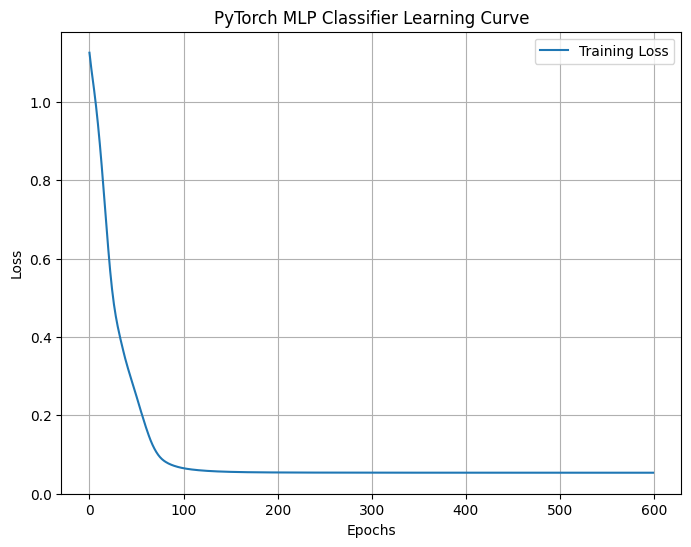

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ==========================================
# Step 1 & 2: Loading and Splitting the Dataset
# ==========================================
# Load the Iris dataset (4 features, 3 classes)
iris = load_iris()
X = iris.data
y = iris.target

# Split the data into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ==========================================
# Step 3: Data Scaling
# ==========================================
# Standardize features to have mean=0 and variance=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert NumPy arrays to PyTorch Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# ==========================================
# Step 4: Building the MLP Model
# ==========================================
# Task 1: Modify the MLP to have different numbers of layers/neurons
class IrisMLP(nn.Module):
    def __init__(self, input_size=4, hidden_size_1=10, hidden_size_2=10, num_classes=3):
        super(IrisMLP, self).__init__()
        # Creating a sequential neural network
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size_1),
            nn.ReLU(),
            nn.Linear(hidden_size_1, hidden_size_2),
            nn.ReLU(),
            nn.Linear(hidden_size_2, num_classes)
            # Note: No Softmax here because nn.CrossEntropyLoss applies it internally
        )

    def forward(self, x):
        return self.network(x)

# Initialize the model using the original 10, 10 structure from the tutorial
mlp_model = IrisMLP(hidden_size_1=10, hidden_size_2=10)

# ==========================================
# Step 5: Training the Model
# ==========================================
# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()

# Task 2: Change the learning rate and observe its effect
learning_rate = 0.01 # Feel free to change this to 0.1, 0.001, etc., to observe convergence speed
optimizer = optim.Adam(mlp_model.parameters(), lr=learning_rate)

# Training Loop
epochs = 600 # Matching the tutorial's output scope
loss_history = []

for epoch in range(epochs):
    # Set model to training mode
    mlp_model.train()

    # 1. Forward pass
    outputs = mlp_model(X_train_t)
    loss = criterion(outputs, y_train_t)

    # 2. Backward pass and optimization
    optimizer.zero_grad() # Clear previous gradients
    loss.backward()       # Compute gradients
    optimizer.step()      # Update weights

    # Track the loss for visualizing the learning curve
    loss_history.append(loss.item())

    # Print progress every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# ==========================================
# Step 6: Evaluating the Model
# ==========================================
# Set model to evaluation mode
mlp_model.eval()

with torch.no_grad(): # Disable gradient calculation for inference
    # Predict the test set results
    test_outputs = mlp_model(X_test_t)
    # Get the predicted class (the index with the highest probability)
    _, y_pred = torch.max(test_outputs, 1)

# Convert tensors back to numpy for Scikit-Learn metrics
y_test_np = y_test_t.numpy()
y_pred_np = y_pred.numpy()

# Evaluate the model
accuracy = accuracy_score(y_test_np, y_pred_np)
print(f'\nAccuracy: {accuracy:.2f}')
print("Classification Report:\n", classification_report(y_test_np, y_pred_np))

# ==========================================
# Step 7: Visualizing the Learning Curve
# ==========================================
# Plot the loss curve
plt.figure(figsize=(8, 6))
plt.plot(loss_history, label='Training Loss')
plt.title('PyTorch MLP Classifier Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()